In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import scipy.interpolate as interp

#import IIF_analysis

datadir = '/Users/idse/data_tmp/signaldecoding/'
datafile = datadir + 'data_expt_20_scaled_norm_bgsub/data/exp20_data_bgsub_scaled_250716.csv';

# which signals and genes are in the data depends on the experiment and should be defined for each dataset
signal_names = ['pSMAD1','ncYAP','BCat','LEF1','ncSMAD23','ncSMAD2','cytopERK','cytopAKT']
signal_names_simplified = ['SMAD1','YAP','BCat','LEF1','SMAD23','SMAD2','ERK','AKT']

gene_names = ['ISL1','GATA3','HAND1','CDX2','TFAP2C','SOX17_1','PRDM1','SNAI1','MIXL1','TBXT','EOMES','TBX6','OCT4','NANOG','SOX2','OTX2']
gene_names_simplified = ['ISL1','GATA3','HAND1','CDX2','TFAP2C','SOX17','PRDM1','SNAI1','MIXL1','TBXT','EOMES','TBX6','OCT4','NANOG','SOX2','OTX2']

feature_names = ['nucArea', 'nucVolume','nucMajorAxis', 'nucMinorAxis', 'nucCircularity', 'CircleEdgeDist']

In [3]:
data = pd.read_csv(datafile, index_col=0).rename_axis('cellID');

In [396]:
class Metadata: 

    def __init__(self):

        self.xres = np.nan;
        self.yres = np.nan;
        self.channels = [];

    def conditionStartPos(self, condition):
        # provide the first position for absa given condition
        print('TODO: implement')

    @property
    def nChannels(self):
        return len(meta.channels)
        

class Position:
    
    def __init__(self, data, posID, meta, features):

        self.cellData = dict();
        
        self.nCells = data.shape[0]
        self.condition = data['condition'].iloc[0]; # called well in matlab
        
        self.cellData['XY'] = data[['X','Y']];
        self.cellData['features'] = data[feature_names];
        self.cellData['intensities'] = data[meta.channels];
        
        self.ID = posID

    def scatter(self, channel, ms=1, vmin=0, vmax=3):
        # make a scatter plot of the colony
        # 
        # channel: color channel 
        # ms : scatter point size
        # vmin, vmax : min and max color
        
        color = self.cellData['intensities'][channel]
        order = color.sort_values().index;
        
        plt.scatter(self.cellData['XY']['X'][order], self.cellData['XY']['Y'][order], s=ms, c=color[order], cmap='YlGnBu', vmin=vmin, vmax=vmax)
        plt.axis('square');
        plt.axis('off');
        
class Colony(Position):
    # Colony extends Position to include features and methods specific to disc-shaped micropatterned colonies, like radiusMicron and makeRadialProfile(..)

    def __init__(self, data, posID, meta, features, nominalRadius):

        super().__init__(data, posID, meta, features)
        self.radiusMicron = nominalRadius
        self.radiusPixel = nominalRadius/meta.xres
        self.center = data[['X','Y']].mean(); # could further clean up by excluding cells outside the colony as in matlab
        self.cellData['XY'] = self.cellData['XY'].assign(edgeDist=data['MetricDist']);
        self.calcRadialProfile()

    def calcRadialProfile(self, cellsPerBin=100, overlap=50):

        Nbins = round(self.nCells/cellsPerBin);
        edges = np.linspace(0,  self.nCells-1, Nbins+1).round().astype(int);
        
        Rs = self.cellData['XY']['edgeDist'];
        I = Rs.sort_values().index;
        
        r_tmp = np.zeros(Nbins)
        profile_tmp = pd.DataFrame(columns=self.cellData['intensities'].columns, index=range(Nbins))
        profile_tmp_std = pd.DataFrame(columns=self.cellData['intensities'].columns, index=range(Nbins))
        
        for i in range(Nbins):
            
            start = max(edges[0], edges[i]-overlap)
            stop = min(edges[i+1]+overlap, edges[-1])
            ptidx = np.arange(start, stop+1) 
            
            sel = I[ptidx]
            r_tmp[i] = np.mean(Rs[sel])
            profile_tmp.loc[i, :] = np.nanmean(self.cellData['intensities'].loc[sel, :], axis=0)
            profile_tmp_std.loc[i, :] = np.nanstd(self.cellData['intensities'].loc[sel, :], axis=0)
            
        # now interpolate on evenly spaced radial bins that allow easy averaging between colonies
        maxR = self.radiusMicron + margin
        Ngrid = round(maxR/dr)
        self.radialGrid = np.linspace(0, maxR, Ngrid);
        
        self.radialProfile = pd.DataFrame(columns=self.cellData['intensities'].columns, index=range(Ngrid))
        self.radialProfile_std = pd.DataFrame(columns=self.cellData['intensities'].columns, index=range(Ngrid))
        
        for c in meta.channels:
            
            # if you get an error from interpolate saying invalid "invalid value encountered in divide", it is because the same r_tmp value occurs twice because cellPerBin < 2* number of cells with edgeDist 0
            interpolator = interp.interp1d(r_tmp, profile_tmp[c], kind='linear', fill_value='extrapolate')
            self.radialProfile[c] = interpolator(self.radialGrid);

            interpolator = interp.interp1d(r_tmp, profile_tmp_std[c], kind='linear', fill_value='extrapolate')
            self.radialProfile_std[c] = interpolator(self.radialGrid);

    def plotRadialProfile(self, channel):

        plt.plot(self.radialGrid, self.radialProfile[channel])

In [397]:
meta = Metadata();
meta.xres = 0.325;
meta.yres = 0.325;
meta.channels = signal_names+gene_names;

In [398]:
col = dict();
for colID in np.unique(data['Colony']):
    col[colID] = Colony(data[data['Colony']==colID], colID, meta, features=feature_names, nominalRadius=350);

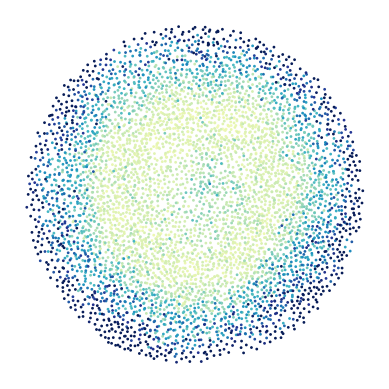

In [399]:
col[1].scatter('pSMAD1')

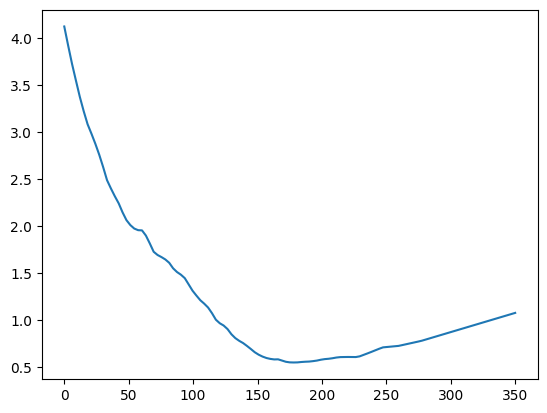

In [400]:
col[1].plotRadialProfile('pSMAD1')